---
<h1 style="text-align:center; font-weight:900">Práctica PLATTS</h1>
<h4 style="text-align:center; font-weight:500">Sofía Maldonado García</h4>
<h4 style="text-align:center; font-weight:500">27/04/2026</h4>

---

In [55]:
# Imports
import pandas as pd
import plotly.express as px
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.pyplot as plt
from pmdarima.arima import auto_arima
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [56]:
df = pd.read_excel("multi_index.xlsx")
df

,Date,PLATTS (EUR/TON)
0,2007-01-03,1135.0
1,2007-01-10,1155.0
2,2007-01-17,1155.0
3,2007-01-24,1155.0
4,2007-01-31,1155.0
...,...,...
966,2026-03-11,1355.0
967,2026-03-18,1455.0
968,2026-03-25,1710.0
969,2026-04-01,1710.0


In [57]:
df = df.rename(columns={"PLATTS (EUR/TON)": "platts"})
df

,Date,platts
0,2007-01-03,1135.0
1,2007-01-10,1155.0
2,2007-01-17,1155.0
3,2007-01-24,1155.0
4,2007-01-31,1155.0
...,...,...
966,2026-03-11,1355.0
967,2026-03-18,1455.0
968,2026-03-25,1710.0
969,2026-04-01,1710.0


### ***Investigación***

El índice **S&P PLATTS** que tenemos aquí mide el precio del Polipropileno en euros por tonelada. Este polímero es derivado del petróleo y es utilizado para construir varias cosas, como en cajas de CD entre otras cosas. Su valor suele estar vinculado al precio del petróleo pero no es tan fluctuante.

Este índice es competitivo ya que es una forma más "segura" y tranquila de invertir en un mercado relacionado con el petróleo. Como se mencionó arriba, es menos fluctuante que el petróleo pero también lo involucra. Aparte, al ser medido solamente una vez a la semana (al menos con esta herramienta) no se abre a la volatilidad que puede suceder en medio de la semana en otros mercados, principalmente y más famosamente como el del petróleo.

In [58]:
fig = px.line(df, x="Date", y="platts")
fig.show()

Como se puede ver, tenemos datos desde el 2007 aquí y este índice ha presentado mucha volatilidad en varios periodos. Específicamente ahora, debido a la guerra en Irán y el cierre del Estrecho de Hormuz, su precio se ha explotado. Por ende, solamente se van a utilizar datos desde el 2024 hasta el presente para hacer las predicciones. Esto nos va a dar unos 2 años de datos de entrenamiento.

In [59]:
fig = px.line(df, x="Date", y="platts")
fig.show()

### ***Modelado***

Estos datos son relativamente sencillos, ya que la acción no sigue alguna forma particular y no tenemos variables exógenas. Tampoco parece haber estacionalidad. Es por esto que considero que un modelo ARIMA podría ser una buena base para hacer predicciones.

In [60]:
# Pruebas de estacionareidad
kpss_test = kpss(df['platts'])
print(f"KPSS: {kpss_test[1]}")

KPSS: 0.01


/tmp/ipykernel_3208/4021978331.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Podemos ver que no es estacionaria. Haciendo un diff

In [61]:
df["platts_diff"] = df["platts"].diff(1)

In [62]:
fig = px.line(df, x="Date", y="platts_diff")
fig.show()

In [63]:
kpss_test = kpss(df['platts_diff'].dropna())
print(f"KPSS: {kpss_test[1]}")

KPSS: 0.1


/tmp/ipykernel_3208/4180923316.py:1: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Después de 1 diff, la serie ya es estacionaria.

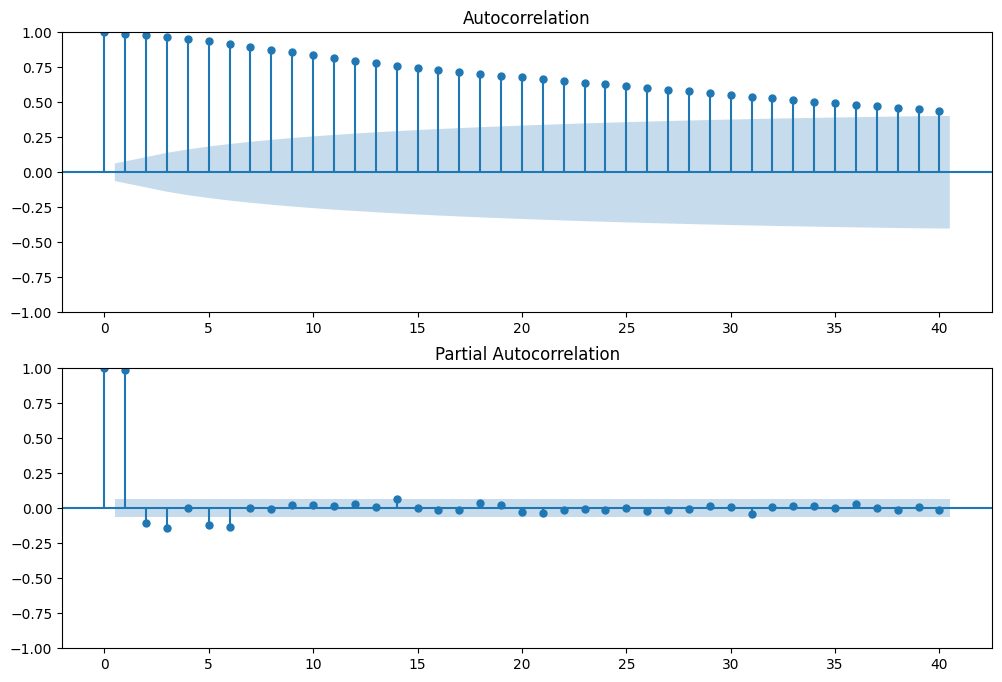

In [64]:
fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['platts'], lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['platts'], lags=40, ax=ax2)

In [65]:
arima_baseline_sm = ARIMA(df['platts'], order=(2,0,1)).fit()
print(arima_baseline_sm.summary())

                               SARIMAX Results                                
Dep. Variable:                 platts   No. Observations:                  971
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -4466.200
Date:                Mon, 27 Apr 2026   AIC                           8942.399
Time:                        21:27:25   BIC                           8966.791
Sample:                             0   HQIC                          8951.683
                                - 971                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1364.3282     69.151     19.730      0.000    1228.795    1499.862
ar.L1          1.8743      0.026     71.179      0.000       1.823       1.926
ar.L2         -0.8780      0.026    -33.403      0.0

In [66]:
preds_baseline = arima_baseline_sm.forecast(13) # Queremos ver 3 meses en el futuro. 13 semanas = 91 días
preds_baseline

971    1905.844720
972    1952.836599
973    1991.878308
974    2023.792384
975    2049.327908
976    2069.166634
977    2083.928636
978    2094.177492
979    2100.425052
980    2103.135816
981    2102.730961
982    2099.592035
983    2094.064355
Name: predicted_mean, dtype: float64

In [67]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x = df.index, y=df["platts"],
    mode="lines",
    name="Training Data"
))

fig.add_trace(go.Scatter(
    x = preds_baseline.index, y=preds_baseline,
    mode="lines",
    name="Predictions"
))

fig.show()

Probando varias opciones, se va a elegir el orden (2,0,1). El p y q se pueden justificar con las gráficas. Sin embargo, el valor d es distinto al que nos dirían las pruebas hipotéticas. Esto se debe a que, usando el valor de d=1, las predicciones son bastante menos conservadoras, explotando más arriba de cualquier valor previamente visto. Esto me parece algo poco realístico (algo en lo que planeo elaborar en la conclusión). Usando d=0, las predicciones son algo más calmadas, al menos durante los próximos 3 meses. 

### ***Intento 2: Redes Neuronales***

Para entretener la idea de un modelo más complejo, ahora se va a utilizar una FFNN. Esta va a ser una red muy sencilla, consistiendo de apenas 3 capas fully-connected (o densas), con una función de activación RELU

In [46]:
train_size = int((len(df)* 0.8))
train_data = df[:train_size]
test_data = df[train_size:]

scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_data[['platts']])
test_scaled = scaler.transform(test_data[['platts']])

# Función para crear ventanas deslizantestrain_size = int((len(df)* 0.8))
train_data = df[:train_size]
test_data = df[train_size:]

scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_data[['platts']])
test_scaled = scaler.transform(test_data[['platts']])

# Función para crear ventanas deslizantes
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X_train, y_train = crear_ventanas(train_scaled, WINDOW_SIZE)
X_test, y_test = crear_ventanas(test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(X_train.shape[0], WINDOW_SIZE)
X_test = X_test.reshape(X_test.shape[0], WINDOW_SIZE)
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X_train, y_train = crear_ventanas(train_scaled, WINDOW_SIZE)
X_test, y_test = crear_ventanas(test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(X_train.shape[0], WINDOW_SIZE)
X_test = X_test.reshape(X_test.shape[0], WINDOW_SIZE)

In [47]:
last_window = test_scaled[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE)
future_scaled = []

In [48]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(optimizer=Adam(), loss='mse')
model.fit(X_train, y_train,
          epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0455 - val_loss: 0.0029
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7548e-04 - val_loss: 0.0011
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6262e-04 - val_loss: 0.0011
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7573e-04 - val_loss: 8.8493e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5137e-04 - val_loss: 0.0011
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9063e-04 - val_loss: 7.7232e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8197e-04 - val_loss: 6.9893e-04
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7126e-04 - val_loss: 6.8644e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1473e-04 - val_loss: 7.1836e-04
Epoch 12/1

In [50]:
y_pred = model.predict(X_test)

y_pred_real = scaler.inverse_transform(y_pred)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [51]:
n = 10

test_x = np.arange(len(train_data), len(train_data) + 7)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_x,
    y=y_test_real.flatten()[-n:],
    mode='lines+markers',
    name='Real',
    marker=dict(symbol='circle')
))

fig.add_trace(go.Scatter(
    x=test_x,
    y=y_pred_real.flatten()[-n:],
    mode='lines+markers',
    name='Predicted',
    marker=dict(symbol='x')
))

fig.update_layout(
    title="Ultimas 10 semanas",
    xaxis_title="Semana",
    yaxis_title="Valor S&P",
)

fig.show()

A comparación del modelo ARIMA, este es algo más conservador con el crecimiento de sus predicciones. 

### ***Preguntas***

**Qué puede esperar un negocio que realiza compras de materiales basados en polipropileno?**

Por ahora, **puede esperar que los precios sigan subiendo**. Al momento de escribir, Estados Unidos e Irán parecen seguir bastante lejos de lograr un acuerdo de paz concreto, y específicamente, un acuerdo que libere el Estrecho de Ormuz. Mientras que este pasaje siga cerrado, especialmente a barcos de países no aliados a Irán, el precio del petróleo seguirá subiendo o, en el mejor de los casos, seguirá siendo impredecible. Esto va a causar que el precio del polipropileno siga subiendo a corto plazo.

**Habrá un periodo de estabilidad? Cuál es su pronóstico de los siguientes meses?**

La apuesta que estoy haciendo con mi pronóstico, en particular mi pronóstico con ARIMA, es que **en unos 2-2.5 meses, Estados Unidos se va a doblar contra Irán** y aceptará alguna paz menos beneficiosa para ellos, para intentar reducir el dolor político que le ha causado a su gobierno el cierre del Estrecho de Ormuz, sobre todo en lo que relaciona a precios de gasolina para auto. Esto haría que los precios de petróleo bajen rápidamente y, junto con ellos, los precios del polipropileno.